# Supervised Learning

### This notebook builds the features and models.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve


In [2]:
os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Data Sources

In [3]:
TEAM_PATH = "data/team_game_truth_2018_2025.parquet"
PLAYER_PATH = "data/player_game_truth_2018_2025.parquet"
LABELS_PATH = "data/cluster_labels_from_modern.parquet"
ARCHETYPES_PATH = "data/player_season_arctyps_fd_2018_2025.parquet"


team_game = pd.read_parquet(TEAM_PATH)
player_game = pd.read_parquet(PLAYER_PATH)
archetypes_fd = pd.read_parquet(ARCHETYPES_PATH)
cluster_labels = pd.read_parquet(LABELS_PATH)

In [4]:
# Get cluster labels
LABEL = {
    (r.pos_group, int(r.cluster)): r.label
    for r in cluster_labels.itertuples(index=False)
}

def get_label(pos_group, cluster):
    return LABEL.get((pos_group, int(cluster)), f"{pos_group}{cluster}")

In [5]:
def pretty_feature(feat):
    base = feat.replace(f"roll{WINDOW}_", "")

    if "F_share_" in base:
        k = int(base.split("F_share_")[1])
        return f"F: {get_label('F', k)}"

    if "D_share_" in base:
        k = int(base.split("D_share_")[1])
        return f"D: {get_label('D', k)}"

    base = base.replace("diff_", "Δ ")
    base = base.replace("cf_percent", "CF%")
    base = base.replace("fo_percent", "FO%")
    base = base.replace("cf60", "CF/60")
    base = base.replace("ca60", "CA/60")
    base = base.replace("toi_es_sec", "ES TOI")
    base = base.replace("_", " ")

    return base

In [6]:
def feature_group(label):
    if label.startswith("F:"):
        return "F"
    elif label.startswith("D:"):
        return "D"
    else:
        return "Other"

# Feature Engineering

In [7]:
team_game["season"] = team_game["season"].astype(str)
team_game["game_id"] = team_game["game_id"].astype(str)

player_game["season"] = player_game["season"].astype(str)
player_game["game_id"] = player_game["game_id"].astype(str)

archetypes_fd["season"] = archetypes_fd["season"].astype(str)

team_game = team_game.sort_values(["team_id", "season", "game_id"]).reset_index(drop=True)

In [8]:
BASE_COLS = [
    "cf_percent", "cf60", "ca60",
    "diff_cf_percent", "diff_cf60", "diff_ca60",
    "shots", "hits", "blocked",
    "takeaways", "giveaways",
    "penalties_taken",
    "fo_percent", "diff_fo_percent",
    "toi_es_sec",
]


In [9]:
WINDOW = 15
MIN_PERIODS = 5

for col in BASE_COLS:
    team_game[f"roll{WINDOW}_{col}"] = (
        team_game
        .groupby(["team_id", "season"])[col]
        .shift(1)
        .rolling(WINDOW, min_periods=MIN_PERIODS)
        .mean()
    )

ROLL_BASE_COLS = [f"roll{WINDOW}_{c}" for c in BASE_COLS]
# len(ROLL_BASE_COLS)

In [10]:
pg = player_game.copy()

pg = pg.merge(
    archetypes_fd[["season", "player_id", "pos_group", "cluster"]],
    on=["season", "player_id"],
    how="left"
)

pg["pos_group"] = pg["pos_group"].fillna("UNK")
pg["cluster"] = pg["cluster"].fillna(-1).astype(int)

den = (
    pg.groupby(["season", "game_id", "team_id"], as_index=False)
      .agg(team_toi_es=("toi_es_sec", "sum"))
)

num = (
    pg.groupby(["season", "game_id", "team_id", "pos_group", "cluster"], as_index=False)
      .agg(cluster_toi_es=("toi_es_sec", "sum"))
)

comp = num.merge(den, on=["season", "game_id", "team_id"], how="left")
comp["toi_share"] = comp["cluster_toi_es"] / comp["team_toi_es"].replace({0: np.nan})

comp_wide = (
    comp.pivot_table(
        index=["season", "game_id", "team_id"],
        columns=["pos_group", "cluster"],
        values="toi_share",
        fill_value=0.0
    )
)

comp_wide.columns = [f"{pos}_share_{cl}" for (pos, cl) in comp_wide.columns]
comp_wide = comp_wide.reset_index()

FD_SHARE_COLS = []
for pos in ["F", "D"]:
    for cl in [0, 1, 2]:
        c = f"{pos}_share_{cl}"
        if c in comp_wide.columns:
            FD_SHARE_COLS.append(c)
        else:
            comp_wide[c] = 0.0
            FD_SHARE_COLS.append(c)

comp_wide = comp_wide[["season", "game_id", "team_id"] + FD_SHARE_COLS]

# comp_wide.head()

In [11]:
team_game2 = team_game.merge(
    comp_wide,
    on=["season", "game_id", "team_id"],
    how="left"
)

team_game2[FD_SHARE_COLS] = team_game2[FD_SHARE_COLS].fillna(0.0)

team_game2 = team_game2.sort_values(["team_id", "season", "game_id"]).reset_index(drop=True)

for col in FD_SHARE_COLS:
    team_game2[f"roll{WINDOW}_{col}"] = (
        team_game2
        .groupby(["team_id", "season"])[col]
        .shift(1)
        .rolling(WINDOW, min_periods=MIN_PERIODS)
        .mean()
    )

ROLL_SHARE_COLS = [f"roll{WINDOW}_{c}" for c in FD_SHARE_COLS]
# len(ROLL_SHARE_COLS)

In [12]:
FEATURE_COLS = ROLL_BASE_COLS + ROLL_SHARE_COLS

df_model = team_game2.dropna(subset=FEATURE_COLS + ["win"]).copy()

df_model["sum_F"] = df_model[[f"roll{WINDOW}_F_share_{k}" for k in [0,1,2]]].sum(axis=1)
df_model["sum_D"] = df_model[[f"roll{WINDOW}_D_share_{k}" for k in [0,1,2]]].sum(axis=1)

# df_model[FEATURE_COLS].head()

# Modeling Setup (Splits + CV + Metrics)

In [13]:
X = df_model[FEATURE_COLS].to_numpy()
y = df_model["win"].astype(int).to_numpy()

groups = (df_model["season"].astype(str) + "_" + df_model["game_id"].astype(str)).to_numpy()

In [14]:
def grouped_cv_scores(model, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    aucs, briers, lls = [], [], []
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
        model.fit(X[tr], y[tr])
        p = model.predict_proba(X[te])[:, 1]

        aucs.append(roc_auc_score(y[te], p))
        briers.append(brier_score_loss(y[te], p))
        lls.append(log_loss(y[te], p))

    cv_scores = {
        "roc_auc_mean": float(np.mean(aucs)),
        "roc_auc_std":  float(np.std(aucs, ddof=1)),
        "brier_mean":   float(np.mean(briers)),
        "brier_std":    float(np.std(briers, ddof=1)),
        "logloss_mean": float(np.mean(lls)),
        "logloss_std":  float(np.std(lls, ddof=1)),
        "fold_roc_auc": aucs,
        "fold_brier": briers,
        "fold_logloss": lls,
    }
    return cv_scores

In [15]:
seasons_sorted = sorted(df_model["season"].unique())

train_seasons = seasons_sorted[:-1]
test_seasons = seasons_sorted[-1:]

train_df = df_model[df_model["season"].isin(train_seasons)].copy()
test_df = df_model[df_model["season"].isin(test_seasons)].copy()

X_train = train_df[FEATURE_COLS].to_numpy()
y_train = train_df["win"].astype(int).to_numpy()

X_test = test_df[FEATURE_COLS].to_numpy()
y_test = test_df["win"].astype(int).to_numpy()

# Models with Hyperparameter

### Logistic Regression

In [16]:
logit_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

In [17]:
logit_results = []

for params in ParameterGrid(logit_grid):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=5000, **params))
    ])
    scores = grouped_cv_scores(model, X, y, groups, n_splits=5)
    logit_results.append({"model_family": "logistic", **params, **scores})

logit_results_df = pd.DataFrame(logit_results).sort_values(
    by=["roc_auc_mean", "brier_mean"], ascending=[False, True]
)

# logit_results_df.head(10)

best_logit = logit_results_df.iloc[0].to_dict()
# best_logit

In [18]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=best_logit["C"],
        penalty="l2",
        solver="lbfgs",
        max_iter=5000
    ))
])

best_model.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(C=0.1, max_iter=5000))])

### Random Forest hyperparameter search

In [19]:
rf_grid = {
    "n_estimators": [300, 600],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
}

In [20]:
rf_results = []

for params in ParameterGrid(rf_grid):
    model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **params
    )
    scores = grouped_cv_scores(model, X, y, groups, n_splits=5)
    rf_results.append({"model_family": "random_forest", **params, **scores})

rf_results_df = pd.DataFrame(rf_results).sort_values(
    by=["roc_auc_mean", "brier_mean"], ascending=[False, True]
)

# rf_results_df.head()

best_rf = rf_results_df.iloc[0].to_dict()
# best_rf

### HistGradientBoosting

In [21]:
hgb_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, None],
    "max_iter": [200, 400],
}

In [22]:
hgb_results = []

for params in ParameterGrid(hgb_grid):
    model = HistGradientBoostingClassifier(
        random_state=42,
        **params
    )
    scores = grouped_cv_scores(model, X, y, groups, n_splits=5)
    hgb_results.append({"model_family": "hist_gb", **params, **scores})

hgb_results_df = pd.DataFrame(hgb_results).sort_values(
    by=["roc_auc_mean", "brier_mean"], ascending=[False, True]
)

# hgb_results_df.head()

best_hgb = hgb_results_df.iloc[0].to_dict()
# best_hgb

In [23]:
temporal_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=best_logit['C'], max_iter=5000))
])

temporal_model.fit(X_train, y_train)

p_test = temporal_model.predict_proba(X_test)[:, 1]
pred_test = (p_test >= 0.5).astype(int)

temporal_scores = {
    "Temporal ROC AUC" :roc_auc_score(y_test, p_test),
    "Temporal Accuracy":accuracy_score(y_test, pred_test),
    "Temporal Brier":brier_score_loss(y_test, p_test),
    "Temporal LogLoss":log_loss(y_test, p_test)
}
temporal_scores_df = pd.DataFrame([temporal_scores])

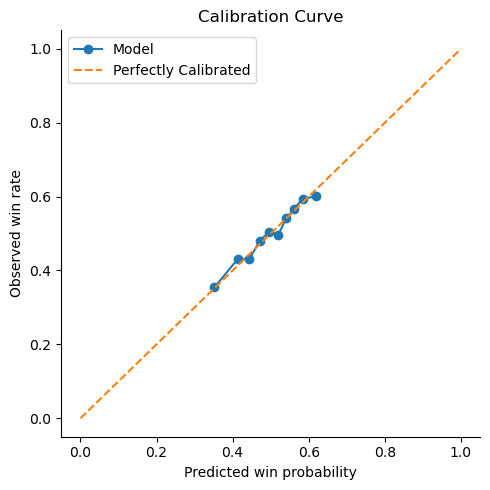

In [24]:
gkf = GroupKFold(n_splits=5)
p_oof = np.zeros_like(y, dtype=float)

for tr, te in gkf.split(X, y, groups):
    best_model.fit(X[tr], y[tr])
    p_oof[te] = best_model.predict_proba(X[te])[:, 1]

frac_pos, mean_pred = calibration_curve(y, p_oof, n_bins=10, strategy="quantile")

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, marker="o", label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfectly Calibrated")

plt.xlabel("Predicted win probability")
plt.ylabel("Observed win rate")
plt.title("Calibration Curve")
plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/calibration_curve_oof.png", dpi=300, bbox_inches="tight")

# Overall Results Table (CV mean ± std)

In [25]:
best_models = [
    best_logit,
    best_rf,
    best_hgb
]

rows = []
for m in best_models:
    rows.append({
        "Model": m["model_family"],
        "ROC AUC (mean ± std)": f"{m['roc_auc_mean']:.5f} ± {m['roc_auc_std']:.5f}",
        "Brier (mean ± std)": f"{m['brier_mean']:.5f} ± {m['brier_std']:.5f}",
        "LogLoss (mean ± std)": f"{m['logloss_mean']:.5f} ± {m['logloss_std']:.5f}"
    })

results_summary = pd.DataFrame(rows)
results_summary

,Model,ROC AUC (mean ± std),Brier (mean ± std),LogLoss (mean ± std)
0,logistic,0.58549 ± 0.00454,0.24437 ± 0.00076,0.68177 ± 0.00157
1,random_forest,0.58530 ± 0.00507,0.24443 ± 0.00093,0.68190 ± 0.00192
2,hist_gb,0.58263 ± 0.00749,0.24480 ± 0.00112,0.68267 ± 0.00230


### Feature Importance 

In [26]:
coef = best_model.named_steps["lr"].coef_[0]

importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

topk = 15
top = importance_df.head(topk).copy()

top["label"] = top["feature"].apply(pretty_feature)

top = top.sort_values("coef")

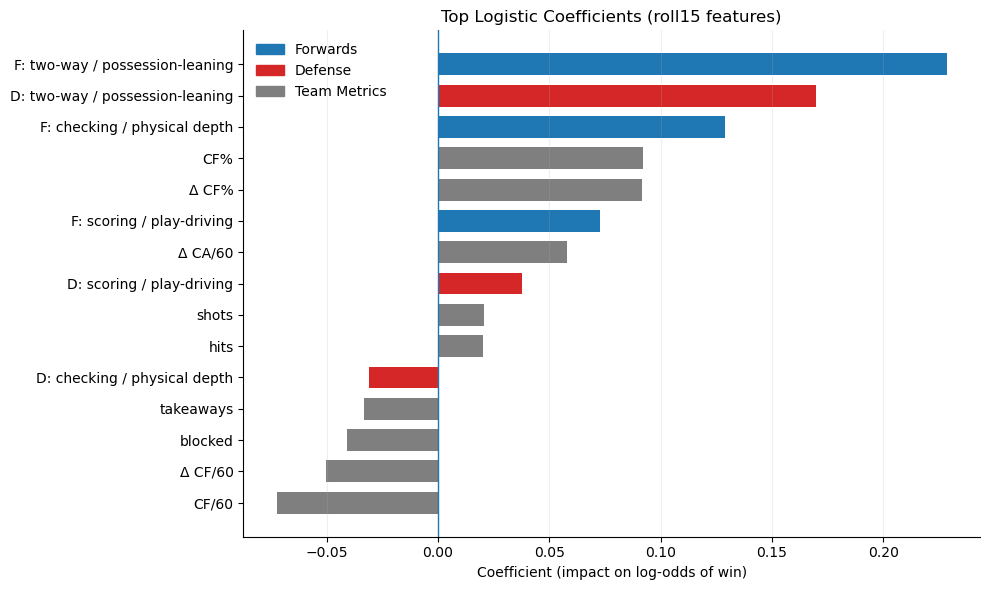

In [27]:
top["group"] = top["label"].apply(feature_group)

color_map = {
    "F": "#1f77b4",   
    "D": "#d62728",   
    "Other": "#7f7f7f"  
}

colors = top["group"].map(color_map)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(top["label"], top["coef"], color=colors, height=0.7)
ax.axvline(0, linewidth=1)

ax.set_title("Top Logistic Coefficients (roll15 features)")
ax.set_xlabel("Coefficient (impact on log-odds of win)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

legend_handles = [
    mpatches.Patch(color="#1f77b4", label="Forwards"),
    mpatches.Patch(color="#d62728", label="Defense"),
    mpatches.Patch(color="#7f7f7f", label="Team Metrics"),
]
ax.legend(handles=legend_handles, frameon=False)
plt.tight_layout()
fig.savefig("figures/logistic_coef_top15.png",dpi=300,bbox_inches="tight")
plt.show()

### Ablation

In [28]:
FEATURES_NO_ARCH = [
    c for c in FEATURE_COLS
    if "F_share" not in c and "D_share" not in c
]

X_no_arch = df_model[FEATURES_NO_ARCH].to_numpy()

### compute CV score for subset

In [29]:
model_no_arch = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=best_logit["C"],
        penalty="l2",
        solver=best_logit["solver"],
        max_iter=5000
    ))
])

scores_no_arch = grouped_cv_scores(
    model_no_arch,
    X_no_arch,
    y,
    groups,
    n_splits=5
)

print("Full ROC AUC:", best_logit["roc_auc_mean"])
print("No Archetype ROC AUC:", scores_no_arch["roc_auc_mean"])

Full ROC AUC: 0.5854893442480501
No Archetype ROC AUC: 0.5651910950855955


### Sensitivity Analysis

In [30]:
logit_results_df[["C","roc_auc_mean"]]

,C,roc_auc_mean
1,0.10,0.585489
0,0.01,0.585459
2,1.00,0.585368
3,10.00,0.585340


# Simulate Lineup Changes


In [31]:
def shift_share_3_preserve_total(v0, v1, v2, total, target, delta, donor=2, eps=1e-12):
    v = np.array([v0, v1, v2], dtype=float)
    v = np.clip(v, 0.0, 1.0)
    total = float(total)
    
    if total < eps:
        return 0.0, 0.0, 0.0
    
    s = v.sum()
    if s > eps:
        v *= (total / s)
    else:
        v[:] = total / 3.0
 
    delta = float(delta)
    delta = max(-v[target], min(delta, total - v[target]))
    if abs(delta) < eps:
        return float(v[0]), float(v[1]), float(v[2])

    if delta > 0:
        need = delta
       
        if donor != target:
            take = min(v[donor], need)
            v[donor] -= take
            v[target] += take
            need -= take
        
        if need > eps:
            other = [i for i in [0, 1, 2] if i not in (target, donor)][0]
            take2 = min(v[other], need)
            v[other] -= take2
            v[target] += take2

    else:
        give = -delta
        v[target] -= give
        if donor != target:
            v[donor] += give
        else:
            other = [i for i in [0, 1, 2] if i != target][0]
            v[other] += give

    v = np.clip(v, 0.0, 1.0)
    s2 = v.sum()
    if s2 > eps:
        v *= (total / s2)

    return float(v[0]), float(v[1]), float(v[2])

In [32]:
def simulate_roll15_archetype_shift_preserve_total(
    row: pd.Series,
    model,
    feature_cols,
    dF0=0.0, dF1=0.0,
    dD0=0.0, dD1=0.0,
    F_donor=2,
    D_donor=2,
):
    x_base = row[feature_cols].to_numpy(dtype=float).reshape(1, -1)
    p_base = float(model.predict_proba(x_base)[:, 1][0])

    F0 = float(row["roll15_F_share_0"]); F1 = float(row["roll15_F_share_1"]); F2 = float(row["roll15_F_share_2"])
    D0 = float(row["roll15_D_share_0"]); D1 = float(row["roll15_D_share_1"]); D2 = float(row["roll15_D_share_2"])

    sum_F = float(row["sum_F"]) if "sum_F" in row.index else (F0 + F1 + F2)
    sum_D = float(row["sum_D"]) if "sum_D" in row.index else (D0 + D1 + D2)

    F0n, F1n, F2n = shift_share_3_preserve_total(F0, F1, F2, total=sum_F, target=0, delta=dF0, donor=F_donor)
    F0n, F1n, F2n = shift_share_3_preserve_total(F0n, F1n, F2n, total=sum_F, target=1, delta=dF1, donor=F_donor)

    D0n, D1n, D2n = shift_share_3_preserve_total(D0, D1, D2, total=sum_D, target=0, delta=dD0, donor=D_donor)
    D0n, D1n, D2n = shift_share_3_preserve_total(D0n, D1n, D2n, total=sum_D, target=1, delta=dD1, donor=D_donor)

    scenario = row.copy()
    scenario["roll15_F_share_0"] = F0n
    scenario["roll15_F_share_1"] = F1n
    scenario["roll15_F_share_2"] = F2n
    scenario["roll15_D_share_0"] = D0n
    scenario["roll15_D_share_1"] = D1n
    scenario["roll15_D_share_2"] = D2n

    scenario["sum_F"] = sum_F
    scenario["sum_D"] = sum_D

    x_scn = scenario[feature_cols].to_numpy(dtype=float).reshape(1, -1)
    p_new = float(model.predict_proba(x_scn)[:, 1][0])

    return {
        "season": scenario.get("season", None),
        "game_id": scenario.get("game_id", None),
        "team_id": scenario.get("team_id", None),
        "p_base": p_base,
        "p_new": p_new,
        "delta_p": p_new - p_base,
        "F_base": (F0, F1, F2),
        "F_new":  (F0n, F1n, F2n),
        "D_base": (D0, D1, D2),
        "D_new":  (D0n, D1n, D2n),
        "sum_F": sum_F,
        "sum_D": sum_D,
    }

In [33]:
def run_batch_simulation_roll15_preserve_total(
    df,
    model,
    feature_cols,
    dF0=0.0, dF1=0.0,
    dD0=0.0, dD1=0.0,
    sample_n=None,
    random_state=42,
    F_donor=2,
    D_donor=2,
):
    df_use = df.sample(sample_n, random_state=random_state) if sample_n else df

    required = [
        "roll15_F_share_0","roll15_F_share_1","roll15_F_share_2",
        "roll15_D_share_0","roll15_D_share_1","roll15_D_share_2",
        "sum_F","sum_D"
    ] + list(feature_cols)

    missing = [c for c in required if c not in df_use.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    out = []
    for _, row in df_use.iterrows():
        out.append(
            simulate_roll15_archetype_shift_preserve_total(
                row=row,
                model=model,
                feature_cols=feature_cols,
                dF0=dF0, dF1=dF1,
                dD0=dD0, dD1=dD1,
                F_donor=F_donor,
                D_donor=D_donor,
            )
        )
    return pd.DataFrame(out)

In [34]:
sim_all = run_batch_simulation_roll15_preserve_total(
    df=df_model,
    model=best_model,
    feature_cols=FEATURE_COLS,
    dF0=0.05,
    F_donor=2,
)

print("Average change in win probability:", round(sim_all["delta_p"].mean(), 6))
print("Expected wins over 82 games:", round(82 * sim_all["delta_p"].mean(), 3))

Average change in win probability: 0.00707
Expected wins over 82 games: 0.58


### Time on Ice change percentages

In [35]:
deltas = [-0.10, -0.05, -0.02, 0.0, 0.02, 0.05, 0.08, 0.10]

results = []

for d in deltas:
    sim = run_batch_simulation_roll15_preserve_total(
        df=df_model,
        model=best_model,
        feature_cols=FEATURE_COLS,
        dF0=d,              # modify THIS cluster
        F_donor=2
    )
    
    mean_delta = sim["delta_p"].mean()
    
    results.append({
        "delta_F0": d,
        "mean_delta_p": mean_delta,
        "wins_per_82": 82 * mean_delta
    })

sensitivity_df = pd.DataFrame(results)
sensitivity_df

,delta_F0,mean_delta_p,wins_per_82
0,-0.10,-0.011800,-0.967627
1,-0.05,-0.005924,-0.485764
2,-0.02,-0.002372,-0.194481
3,0.00,0.000000,0.000000
4,0.02,0.002601,0.213276
5,0.05,0.007070,0.579769
6,0.08,0.012389,1.015907
7,0.10,0.016297,1.336378


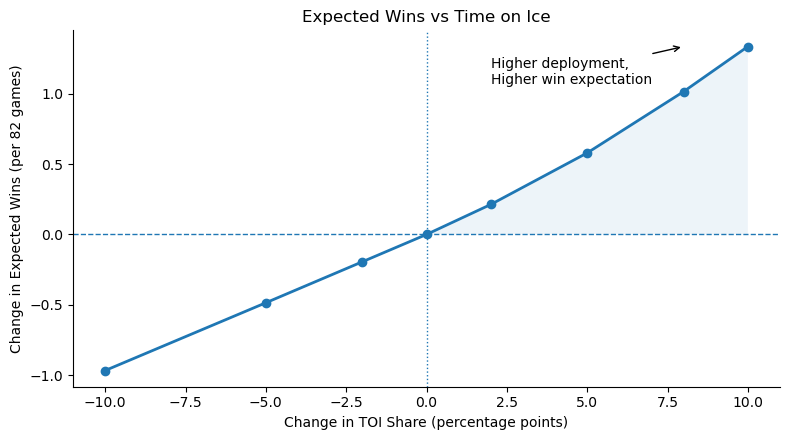

In [36]:
x_vals = 100 * sensitivity_df["delta_F0"]
y_vals = sensitivity_df["wins_per_82"]

fig, ax = plt.subplots(figsize=(8,4.5))

ax.plot(x_vals, y_vals, marker="o", linewidth=2)
ax.fill_between(x_vals, 0, y_vals, where=(y_vals >= 0), alpha=0.08)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle=":", linewidth=1)

ax.set_xlabel(f"Change in TOI Share (percentage points)")
ax.set_ylabel("Change in Expected Wins (per 82 games)")
ax.set_title("Expected Wins vs Time on Ice")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.annotate(
    "Higher deployment, \nHigher win expectation",
    xy=(8, y_vals.iloc[-1]),
    xytext=(2, y_vals.max()*0.8),
    arrowprops=dict(arrowstyle="->"),
)

plt.tight_layout()
plt.savefig("figures/sensitivity_forward_archetype0.png", dpi=300)
plt.show()

# Failure Analysis

In [37]:
p_full = best_model.predict_proba(X)[:, 1]

df_model["pred_prob"] = p_full
df_model["pred_class"] = (p_full >= 0.5).astype(int)
df_model["correct"] = (df_model["pred_class"] == df_model["win"]).astype(int)

print("accuracy:", df_model["correct"].mean())

accuracy: 0.5629835232977027


In [38]:
failures = df_model[df_model["correct"] == 0].copy()

print("total", len(df_model))
print("failures", len(failures))
print("failure rate", round(len(failures)/len(df_model), 3))

total 16933
failures 7400
failure rate 0.437


In [39]:
# Set Failure categories

# (A) High-confidence but wrong: model was (<0.30 or >0.70)
high_conf_fail = failures[(failures["pred_prob"] < 0.30) | (failures["pred_prob"] > 0.70)].copy()
high_conf_fail = high_conf_fail.sort_values("pred_prob")  
example_high = high_conf_fail.iloc[0]

# (B) Close-call but wrong: model was (near 0.5) 
close_fail = failures[(failures["pred_prob"] > 0.48) & (failures["pred_prob"] < 0.52)].copy()

close_fail = close_fail[close_fail["game_id"] != example_high["game_id"]]
example_close = close_fail.iloc[0]

# (C) Possession-dominant but lost: strong CF% but still lost

possession_fail = failures[(failures["cf_percent"] > 0.55) & (failures["win"] == 0)].copy()
possession_fail = possession_fail[
    ~possession_fail["game_id"].isin([example_high["game_id"], example_close["game_id"]])
]
example_possession = possession_fail.iloc[0]

In [40]:
cols_to_show = [
    "season","game_id","team_id","opp_team_id","win","pred_prob","pred_class",
    "cf_percent","roll15_cf_percent","roll15_diff_cf_percent",
    "roll15_F_share_0","roll15_F_share_1","roll15_F_share_2",
    "roll15_D_share_0","roll15_D_share_1","roll15_D_share_2"
]

In [41]:
failure_examples = pd.concat([
    example_high[cols_to_show].to_frame().T.assign(Category="High-Confidence Miss"),
    example_close[cols_to_show].to_frame().T.assign(Category="Close-Call Miss"),
    example_possession[cols_to_show].to_frame().T.assign(Category="Possession-Dominant Loss"),
], ignore_index=True)

cols = ["Category"] + [c for c in failure_examples.columns if c != "Category"]
failure_examples = failure_examples[cols]
failure_examples["pred_prob"] = failure_examples["pred_prob"].astype(float).round(3)

failure_examples

,Category,season,game_id,team_id,opp_team_id,win,pred_prob,pred_class,cf_percent,roll15_cf_percent,roll15_diff_cf_percent,roll15_F_share_0,roll15_F_share_1,roll15_F_share_2,roll15_D_share_0,roll15_D_share_1,roll15_D_share_2
0,High-Confidence Miss,20232024,2023020705,16,2,1,0.263,0,0.479798,0.468617,-0.062767,0.082967,0.442856,0.023233,0.015778,0.382235,0.0
1,Close-Call Miss,20182019,2018020102,1,4,0,0.515,1,0.512195,0.557888,0.115776,0.321518,0.094302,0.103629,0.204549,0.196783,0.0
2,Possession-Dominant Loss,20182019,2018020559,1,29,0,0.517,1,0.576659,0.490816,-0.018369,0.376749,0.097061,0.10377,0.206232,0.186268,0.007537


# Goal Differential Regression and Analysis

In [42]:
df_reg = df_model.copy()

df_reg["goal_diff"] = (
    df_reg["goals_for"] - df_reg["goals_against"]
)

print("Goal differential summary:")
df_reg["goal_diff"].describe()

Goal differential summary:


count    16933.000000
mean        -0.000650
std          2.614753
min         -9.000000
25%         -2.000000
50%         -1.000000
75%          2.000000
max          9.000000
Name: goal_diff, dtype: float64

In [43]:
X_reg = df_reg[FEATURE_COLS].to_numpy()
y_reg = df_reg["goal_diff"].to_numpy()
groups_reg = df_reg["game_id"].astype(str).to_numpy()

In [44]:
def grouped_cv_scores_reg(model, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    rmses, maes, r2s = [], [], []

    for tr, te in gkf.split(X, y, groups):
        model.fit(X[tr], y[tr])
        preds = model.predict(X[te])

        rmses.append(np.sqrt(mean_squared_error(y[te], preds)))
        maes.append(mean_absolute_error(y[te], preds))
        r2s.append(r2_score(y[te], preds))

    return {
        "rmse_mean": np.mean(rmses),
        "rmse_std": np.std(rmses),
        "mae_mean": np.mean(maes),
        "mae_std": np.std(maes),
        "r2_mean": np.mean(r2s),
        "r2_std": np.std(r2s),
    }

### Linear Regression

In [45]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_scores = grouped_cv_scores_reg(
    ridge_model,
    X_reg,
    y_reg,
    groups_reg
)

ridge_scores

{'rmse_mean': 2.5735915261090723,
 'rmse_std': 0.03872185627576826,
 'mae_mean': 2.189970170768368,
 'mae_std': 0.03140879347536521,
 'r2_mean': 0.030914294806373734,
 'r2_std': 0.0028652905671826497}

### Random Forest Regressor

In [46]:
rf_reg = RandomForestRegressor(
    n_estimators=600,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_scores = grouped_cv_scores_reg(
    rf_reg,
    X_reg,
    y_reg,
    groups_reg
)

rf_scores

{'rmse_mean': 2.575028185534328,
 'rmse_std': 0.03837306196092887,
 'mae_mean': 2.191434737644772,
 'mae_std': 0.03195891625438762,
 'r2_mean': 0.02982273196550602,
 'r2_std': 0.004191769419907441}

### Hist Gradient Boosting Regressor

In [47]:
hgb_reg = HistGradientBoostingRegressor(
    max_depth=3,
    learning_rate=0.03,
    max_iter=200,
    random_state=42
)

hgb_scores = grouped_cv_scores_reg(
    hgb_reg,
    X_reg,
    y_reg,
    groups_reg
)

hgb_scores

{'rmse_mean': 2.576232456808462,
 'rmse_std': 0.03909993264415574,
 'mae_mean': 2.1993017578358844,
 'mae_std': 0.03240079693114171,
 'r2_mean': 0.028929800713623343,
 'r2_std': 0.0022792453012792043}

In [48]:
from sklearn.base import clone
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
pred_oof = np.zeros_like(y_reg, dtype=float)

for tr, te in gkf.split(X_reg, y_reg, groups_reg):
    m = clone(ridge_model)   # or rf_reg / hgb_reg
    m.fit(X_reg[tr], y_reg[tr])
    pred_oof[te] = m.predict(X_reg[te])

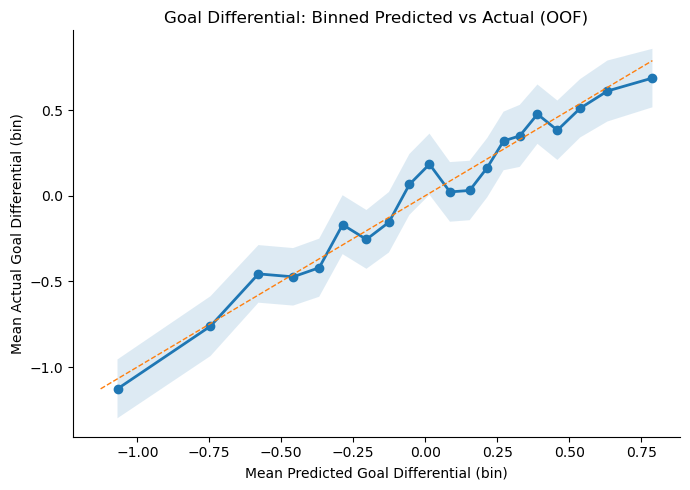

In [49]:
plot_df = pd.DataFrame({"y": y_reg, "pred": pred_oof}).dropna()

plot_df["bin"] = pd.qcut(plot_df["pred"], q=20, duplicates="drop")

binned = plot_df.groupby("bin").agg(
    pred_mean=("pred", "mean"),
    y_mean=("y", "mean"),
    n=("y", "size"),
    y_std=("y", "std"),
).reset_index()

binned["y_se"] = binned["y_std"] / np.sqrt(binned["n"].clip(lower=1))

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(binned["pred_mean"], binned["y_mean"], marker="o", linewidth=2)
ax.fill_between(
    binned["pred_mean"],
    binned["y_mean"] - 1.96 * binned["y_se"],
    binned["y_mean"] + 1.96 * binned["y_se"],
    alpha=0.15
)

lims = [
    min(binned["pred_mean"].min(), binned["y_mean"].min()),
    max(binned["pred_mean"].max(), binned["y_mean"].max())
]
ax.plot(lims, lims, linestyle="--", linewidth=1)

ax.set_xlabel("Mean Predicted Goal Differential (bin)")
ax.set_ylabel("Mean Actual Goal Differential (bin)")
ax.set_title("Goal Differential: Binned Predicted vs Actual (OOF)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("figures/goal_diff_binned_pred_vs_actual_oof.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
reg_summary = pd.DataFrame([
    {
        "Model": "Ridge",
        "RMSE": f"{ridge_scores['rmse_mean']:.3f} ± {ridge_scores['rmse_std']:.3f}",
        "MAE": f"{ridge_scores['mae_mean']:.3f} ± {ridge_scores['mae_std']:.3f}",
        "R2": f"{ridge_scores['r2_mean']:.3f} ± {ridge_scores['r2_std']:.3f}",
    },
    {
        "Model": "Random Forest",
        "RMSE": f"{rf_scores['rmse_mean']:.3f} ± {rf_scores['rmse_std']:.3f}",
        "MAE": f"{rf_scores['mae_mean']:.3f} ± {rf_scores['mae_std']:.3f}",
        "R2": f"{rf_scores['r2_mean']:.3f} ± {rf_scores['r2_std']:.3f}",
    },
    {
        "Model": "HistGB",
        "RMSE": f"{hgb_scores['rmse_mean']:.3f} ± {hgb_scores['rmse_std']:.3f}",
        "MAE": f"{hgb_scores['mae_mean']:.3f} ± {hgb_scores['mae_std']:.3f}",
        "R2": f"{hgb_scores['r2_mean']:.3f} ± {hgb_scores['r2_std']:.3f}",
    }
])

reg_summary

,Model,RMSE,MAE,R2
0,Ridge,2.574 ± 0.039,2.190 ± 0.031,0.031 ± 0.003
1,Random Forest,2.575 ± 0.038,2.191 ± 0.032,0.030 ± 0.004
2,HistGB,2.576 ± 0.039,2.199 ± 0.032,0.029 ± 0.002


### Save summaries

In [51]:
results_summary.to_csv("artifacts/results_summary.csv", index=False)
sensitivity_df.to_csv("artifacts/sensitivity_forward_F0.csv", index=False)
failure_examples.to_csv("artifacts/failure_examples.csv", index=False)
reg_summary.to_csv("artifacts/regression_summary.csv", index=False)
logit_results_df.to_csv("artifacts/tuning_logit.csv", index=False)
rf_results_df.to_csv("artifacts/tuning_rf.csv", index=False)
hgb_results_df.to_csv("artifacts/tuning_hgb.csv", index=False)
temporal_scores_df.to_csv("artifacts/temporal_holdout_scores.csv", index=False)